In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))

# Importar as tuas classes de raiz
from utils import prepare_text_data
from neuralnet import NeuralNetwork
from layers import DenseLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy

In [20]:
# Carregar o dataset real
df = pd.read_csv('../data/dataset.csv').dropna()

# Extrair listas
textos = df['text'].tolist()
labels = df['label'].tolist()

# Preparar dados: TF-IDF (500 colunas) e One-Hot Encoding para 5 classes
X_train, Y_train, X_val, Y_val, X_test, Y_test, vectorizer, encoder = prepare_text_data(
    textos, 
    labels, 
    max_features=500,  
    test_size=0.2,     
    val_size=0.1,      
    use_stratify=True 
)

print(f"✅ Setup Concluído!")
print(f"Input Dim: {X_train.shape[1]} | Classes: {encoder.categories_[0]}")

✅ Setup Concluído!
Input Dim: 500 | Classes: ['google' 'human' 'meta' 'mistral' 'openai']


In [21]:
# Definir dimensões
input_dim = X_train.shape[1] 
output_dim = Y_train.shape[1] # Deve ser 5

# Montar a rede
nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())

lr = 0.01
mom = 0.9

# Camada 1: Input -> 256 
nn.add(DenseLayer(input_shape=input_dim, n_units=256, learning_rate=lr, momentum=mom))
nn.add(ReLUActivation()) 

# Camada 2: 256 -> 128 
nn.add(DenseLayer(input_shape=256, n_units=64, learning_rate=lr, momentum=mom))
nn.add(ReLUActivation())

# Camada 3: 128 -> 64
nn.add(DenseLayer(input_shape=64, n_units=32, learning_rate=lr, momentum=mom))
nn.add(ReLUActivation())

# Camada de Saída: 64 -> 5
nn.add(DenseLayer(input_shape=32, n_units=output_dim, learning_rate=lr, momentum=mom))
nn.add(SoftmaxActivation())

criterion = CategoricalCrossEntropy()

print("Rede Neuronal montada com sucesso!")

Rede Neuronal montada com sucesso!


In [22]:
epochs = 100
batch_size = 32   

print("A iniciar o treino no Numpy...")
nn.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=True)

A iniciar o treino no Numpy...
Epoch 1/100 | Loss: 1.5967
Epoch 11/100 | Loss: 0.4708
Epoch 21/100 | Loss: 0.2914
Epoch 31/100 | Loss: 0.1666
Epoch 41/100 | Loss: 0.1582
Epoch 51/100 | Loss: 0.0603
Epoch 61/100 | Loss: 0.0522
Epoch 71/100 | Loss: 0.0539
Epoch 81/100 | Loss: 0.0698
Epoch 91/100 | Loss: 0.0555
Epoch 100/100 | Loss: 0.0471


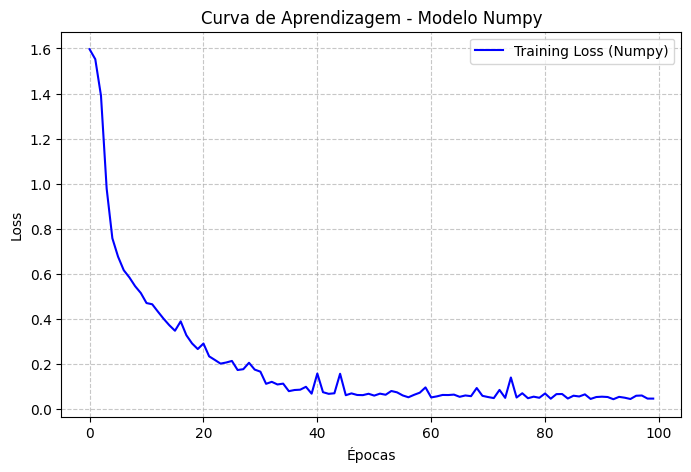

Resultados do Modelo Numpy:
Teste Loss: 1.8383
Teste Accuracy: 64.31%


In [23]:
# 1. Desenhar a curva de Loss
plt.figure(figsize=(8, 5))
plt.plot(nn.history['loss'], label='Training Loss (Numpy)', color='blue')
plt.title('Curva de Aprendizagem - Modelo Numpy')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 2. Avaliar nos dados de teste
test_loss, test_acc = nn.evaluate(X_test, Y_test)
print(f"Resultados do Modelo Numpy:")
print(f"Teste Loss: {test_loss:.4f}")
print(f"Teste Accuracy: {test_acc*100:.2f}%")

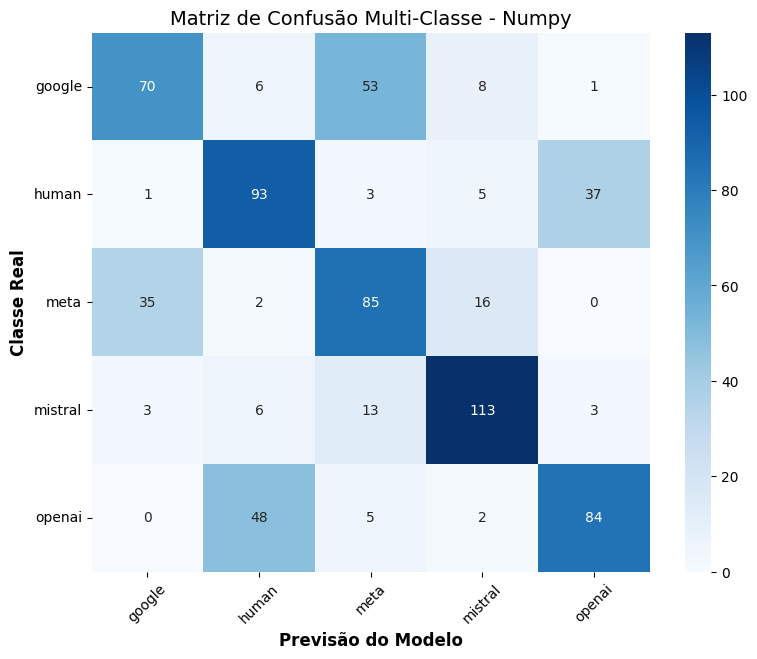

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Obter as probabilidades da rede para os dados de teste
# Nota: Garante que 'forward_propagation' é o método correto da tua classe
y_pred_proba = nn.forward_propagation(X_test)

# 2. Converter previsões e labels reais de One-Hot para índices
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test, axis=1)

# 3. Criar a matriz usando os nomes das classes (categories_)
cm = confusion_matrix(y_true, y_pred)
class_names = encoder.categories_[0]

# 4. Plotar o gráfico (Versão Melhorada)
plt.figure(figsize=(9, 7)) # Ligeiramente maior para caber as 5 classes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusão Multi-Classe - Numpy', fontsize=14)

# Rodar as labels do eixo X para facilitar a leitura
plt.xticks(rotation=45) 
plt.yticks(rotation=0)

plt.show()